In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

class ResultState(TypedDict):
     value1:int
     value2:int
     result:int


In [3]:
def add(state:ResultState) -> ResultState:
    state['result'] = state['value1'] + state['value2']
    return state

In [4]:
def sub(state:ResultState) -> ResultState:
    state['result'] = state['value1'] - state['value2']
    return state

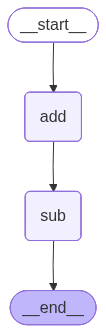

In [5]:
from utils import draw_graph
state_graph =  StateGraph(ResultState)
#state_graph.add_node(START,'add')
state_graph.add_node('add',add)
state_graph.add_node('sub',sub)
state_graph.set_entry_point('add')
state_graph.add_edge('add','sub')
state_graph.set_finish_point('sub')
graph = state_graph.compile()

draw_graph(graph)

In [6]:

state = ResultState(value1 = 10, value2= 3)
result = graph.invoke(state)
print(result)

{'value1': 10, 'value2': 3, 'result': 7}


# to prevent overriding
# approch 1
''' python 
   class ResultState(TypeDict):
     value1:int
     value2:int
     add_result:int
     sub_result:int
# approch 2
 class ResultState(TypeDict):
     value1:int
     value2:int
     result: list[int]''''
    

# It is not  nessary that every node has to retrun the complete state
#partial Updates are also ok



In [ ]:
import operator
from typing import Annotated, TypedDict

# Import the necessary LangGraph components
from langgraph.graph import StateGraph, START, END

# 1. Define the state schema correctly
# The keys (e.g., 'value1') are simple variable names.
# The value is the annotated type.
class ResultStateIndividual(TypedDict):
    value1: Annotated[int, operator.add]
    value2: Annotated[int, operator.add]
    add_result: Annotated[int, operator.add]
    sub_result: Annotated[int, operator.add]

# 2. Define the nodes
def set_values(state: ResultStateIndividual) -> ResultStateIndividual:
    # This node sets the initial values.
    # The 'operator.add' reducer is used, so any subsequent updates will be added.
    print("Setting initial values...")
    return {'value1': 10, 'value2': 5}

def add(state: ResultStateIndividual) -> ResultStateIndividual:
    print(f"Adding {state['value1']} and {state['value2']}")
    # The state is updated with the new result.
    return {'add_result': state['value1'] + state['value2']}

def sub(state: ResultStateIndividual) -> ResultStateIndividual:
    print(f"Subtracting {state['value2']} from {state['value1']}")
    # The state is updated with the new result.
    return {'sub_result': state['value1'] - state['value2']}




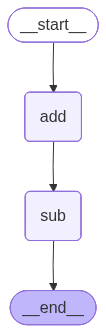

In [14]:
state_graph =  StateGraph(ResultStateIndividual)
#state_graph.add_node(START,'add')
state_graph.add_node('add',add)
state_graph.add_node('sub',sub)
state_graph.set_entry_point('add')
state_graph.add_edge('add','sub')
state_graph.set_finish_point('sub')
graph = state_graph.compile()

draw_graph(graph)

In [15]:
result = graph.invoke({"value1": 10, "value2": 3})

In [ ]:
result

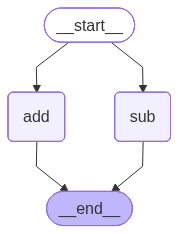

In [19]:
seq_graph = StateGraph(ResultStateIndividual)
seq_graph.add_node("add", add)
seq_graph.add_node("sub", sub)
seq_graph.add_edge(START, "add")
seq_graph.add_edge("add", END)
seq_graph.add_edge(START, "sub")
seq_graph.add_edge("sub", END)
graph = seq_graph.compile()

draw_graph(graph)

In [25]:
# 3. Build and compile the graph
builder = StateGraph(ResultStateIndividual)
builder.add_node("set_values", set_values)
builder.add_node("add", add)
builder.add_node("sub", sub)

builder.add_edge(START, "set_values")
builder.add_edge("set_values", "add")
builder.add_edge("add", "sub")
builder.add_edge("sub", END)

app = builder.compile()

# 4. Invoke the graph with initial state, including default values
# Note: Initial values must be provided during invocation, not in the class definition.
initial_state = {
    'value1': 0, 
    'value2': 0, 
    'add_result': 0, 
    'sub_result': 0
}

result = app.invoke(initial_state)

# 5. Print the final state to verify
print("\nFinal state:", result)

Setting initial values...
Adding 10 and 5
Subtracting 5 from 10

Final state: {'value1': 10, 'value2': 5, 'add_result': 15, 'sub_result': 5}


In [26]:
result

{'value1': 10, 'value2': 5, 'add_result': 15, 'sub_result': 5}

In [1]:

import ipywidgets as widgets
# Create interactive widgets
value1_input = widgets.IntText(
    value=10,
    description='Value 1:',
    disabled=False
)

value2_input = widgets.IntText(
    value=5,
    description='Value 2:',
    disabled=False
)

run_button = widgets.Button(
    description='Run Graph',
    button_style='success',
    tooltip='Click to run the graph',
    icon='play'
)

# Display the widgets
display(value1_input, value2_input, run_button)


ModuleNotFoundError: No module named 'ipywidgets'